# 1주차 과제: 서울시 따릉이 데이터로 시각화 및 전처리

지난 회차에는 pandas **문법**을 배웠습니다. 인덱싱, 필터링 같은 것들요.
 
이번에 새로 배우는 건 `groupby` 입니다

## 주요 질문

| | 질문 | 쓰는 도구 |
| --- | --- | --- |
| Q1 | 하루 중 자전거를 언제 가장 많이 빌릴까? | `groupby` + 선그래프 |
| Q2 | 계절에 따라 다를까? | `groupby` + 막대그래프 |
| Q3 | 평일과 주말의 차이? | 요일 만들기 + 그래프 |
| Q4 | 날씨와의 상관관계? | 필터링 + 산점도 |
| Q5 | 결측지는 어떻게 처리하지? | 필터링 + 평균 비교 |

## 데이터 정보

2017년 12월부터 2018년 11월까지, **한 시간에 자전거가 몇 대 대여됐는지**를 그때의 날씨와 함께 기록된 서울시 따릉이 데이터입니다. 
한 줄이 한 시간이라서 365일 × 24시간 = 8,760줄입니다.

## 진행 방법

- 셀을 실행해보고, 코드 중간중간에 # 로 주석을 달아서 설명 남기기, 그리고 본인의 생각도 같이 남기기 

데이터 출처: [UCI Seoul Bike Sharing Demand](https://archive.ics.uci.edu/dataset/560/seoul%2Bbike%2Bsharing%2Bdemand) / 라이선스: CC BY 4.0

## 1. 세팅

### 1-1. 라이브러리 불러오기

- `pandas`: 표 데이터를 다루는 도구 
- `matplotlib`: 그래프를 그리는 도구
- `seaborn`: `matplotlib`을 더 쉽게 쓰게 해주는 도구. 짧은 코드로 예쁜 그래프를 그려줍니다

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

print("준비 완료")

준비 완료


### 1-2. 데이터 불러오기

`pd.read_csv()`로 CSV 파일을 읽습니다. 같은 폴더에 파일이 있으면 그걸 쓰고, 없으면 인터넷에서 내려받아요.

`encoding="latin1"`이 붙어 있는데, 간단하게 "이 파일을 읽으려면 필요한 옵션" 정도로 넘어가셔도 됩니다.

In [3]:
LOCAL_CSV = Path("SeoulBikeData.csv")
SOURCE_URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"

if LOCAL_CSV.exists():
    df = pd.read_csv(LOCAL_CSV, encoding="latin1")
    print("로컬 파일에서 읽었습니다.")
else:
    df = pd.read_csv(SOURCE_URL, compression="zip", encoding="latin1")
    # compression="zip" 압축파일을 풀면서 읽을 것
    df.to_csv(LOCAL_CSV, index=False, encoding="latin1")
    # index=False? 필요없는 열을 csv를 다운받을 때 추가하지 않기 위함
    print("인터넷에서 내려받았습니다. (다음부터는 저장된 파일을 씁니다)")

print("\n원래 열 이름:")
print(list(df.columns))

로컬 파일에서 읽었습니다.

원래 열 이름:
['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons', 'Holiday', 'Functioning Day']


### 1-3. 열 이름 바꾸기

원래 열 이름은 `Temperature(°C)`처럼 공백과 특수문자가 섞여 있어서 코드로 쓰기 번거롭습니다. 짧고 치기 쉬운 이름으로 바꿔둘게요.

| 바꾼 이름 | 뜻 |
| --- | --- |
| `date` | 날짜 |
| `rent_count` | **그 시간에 대여된 자전거 수** |
| `hour` | 시각 (0~23) |
| `temp` | 기온 (°C) |
| `humidity` | 습도 (%) |
| `wind` | 풍속 (m/s) |
| `visibility` | 가시거리 |
| `dew_point` | 이슬점 온도 |
| `solar` | 일사량 |
| `rain` | 강수량 (mm) |
| `snow` | 적설량 (cm) |
| `season` | 계절 |
| `holiday` | 공휴일 여부 |
| `is_open` | 그날 따릉이를 운영했는지 (`Yes` / `No`) |

In [4]:
df.columns = [
    "date", "rent_count", "hour", "temp", "humidity", "wind",
    "visibility", "dew_point", "solar", "rain", "snow",
    "season", "holiday", "is_open",
]

df.head()
# 상위 몇 개 행을 출력. 기본 상위 5개 행

,date,rent_count,hour,temp,humidity,wind,visibility,dew_point,solar,rain,snow,season,holiday,is_open
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


### 1-4. 데이터 훑어보기

데이터를 분석할때 가장 먼저 우리가 어떤 데이터를 다뤄야하는지 알아야하니깐, 먼저 이 4개를 진행을 합니다.

`shape` (크기) → `info()` (타입과 빈칸) → `describe()` (숫자 요약) → `isna().sum()` (빈칸 개수)

In [5]:
print("행 개수, 열 개수:", df.shape)
print(f"→ {df.shape[0]:,}행 × {df.shape[1]}열")
# ':,' 천 단위 쉼표를 넣을 것
print()
df.info()

행 개수, 열 개수: (8760, 14)
→ 8,760행 × 14열

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        8760 non-null   object 
 1   rent_count  8760 non-null   int64  
 2   hour        8760 non-null   int64  
 3   temp        8760 non-null   float64
 4   humidity    8760 non-null   int64  
 5   wind        8760 non-null   float64
 6   visibility  8760 non-null   int64  
 7   dew_point   8760 non-null   float64
 8   solar       8760 non-null   float64
 9   rain        8760 non-null   float64
 10  snow        8760 non-null   float64
 11  season      8760 non-null   object 
 12  holiday     8760 non-null   object 
 13  is_open     8760 non-null   object 
dtypes: float64(6), int64(4), object(4)
memory usage: 958.3+ KB


`info()` 읽는 법입니다.

- `int64` = 정수, `float64` = 소수, `object`나 `str` = 글자
- `Non-Null Count`가 전체 행 수(8,760)와 같으면 **빈 데이터가 없다**는 뜻입니다
- `date`가 지금 글자(`object`/`str`)라는 점을 기억해두세요. Q3에서 이걸 날짜로 바꿀 거예요

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
rent_count,8760.0,704.602055,644.997468,0.0,191.00,504.50,1065.25,3556.00
hour,8760.0,11.500000,6.922582,0.0,5.75,11.50,17.25,23.00
temp,8760.0,12.882922,11.944825,-17.8,3.50,13.70,22.50,39.40
humidity,8760.0,58.226256,20.362413,0.0,42.00,57.00,74.00,98.00
wind,8760.0,1.724909,1.036300,0.0,0.90,1.50,2.30,7.40
visibility,8760.0,1436.825799,608.298712,27.0,940.00,1698.00,2000.00,2000.00
dew_point,8760.0,4.073813,13.060369,-30.6,-4.70,5.10,14.80,27.20
solar,8760.0,0.569111,0.868746,0.0,0.00,0.01,0.93,3.52
rain,8760.0,0.148687,1.128193,0.0,0.00,0.00,0.00,35.00
snow,8760.0,0.075068,0.436746,0.0,0.00,0.00,0.00,8.80


`describe()`는 숫자 열만 요약해줍니다.

- `mean` 평균 / `50%` 중앙값(딱 가운데 값) / `min` 최소 / `max` 최대
- `rent_count`를 보시면 평균은 704.6인데 중앙값은 504.5입니다. 이런 형태는 통계적으로 어떤 형태의 분포인지 생각해 볼 필요도 있어요!

In [7]:
for column in ["season", "holiday", "is_open"]:
    print(f"[{column}]")
    # 변수값이 {}에 들어감
    print(df[column].value_counts())
    # value_counts() 각 값이 몇 번 나오는지 세는 것 -> 범주형 데이터 분포 확인
    print()
    # 빈 줄 출력

[season]
season
Spring    2208
Summer    2208
Autumn    2184
Winter    2160
Name: count, dtype: int64

[holiday]
holiday
No Holiday    8328
Holiday        432
Name: count, dtype: int64

[is_open]
is_open
Yes    8465
No      295
Name: count, dtype: int64



`is_open`에 `No`가 295개 있는 게 보이시나요? 따릉이를 운영하지 않은 시간입니다. 이런 데이터들은 어떻게 처리해야되는지 나중에 확인해볼거에요.

## 2. `groupby`

### 2-1. 지난 회차 방식으로 해보기

만약에 우리가 저번에 배웠던 필터링으로 "계절마다 평균 대여량이 얼마나 다를까?" 를 한다면 아래와 같이 코드가 쓰일거에요

In [8]:
summer = df[df["season"] == "Summer"]
# df["season"] == "Summer" -> true or false
# df[df["season"] == "Summer"] -> true인 행만 남길것
print("여름 평균:", round(summer["rent_count"].mean(), 1))

winter = df[df["season"] == "Winter"]
print("겨울 평균:", round(winter["rent_count"].mean(), 1))

여름 평균: 1034.1
겨울 평균: 225.5


잘 됩니다. 그런데 계절이 네 개니까 이걸 네 번 반복해야 해요. 만약 기준이 요일(7개)이나 시간(24개)이라면 24번을 써야 합니다. 그건 좀 비효율적이죠...?

### 2-2. `groupby`로 한 줄에 끝내기

`groupby`는 "이 기준으로 데이터를 묶어서, 묶음마다 계산해줘" 라는 뜻입니다.

In [27]:
df.groupby("season")["rent_count"].mean().round(1)

season
Autumn     819.6
Spring     730.0
Summer    1034.1
Winter     225.5
Name: rent_count, dtype: float64

한 줄로 네 계절이 다 나왔습니다. 여름·겨울 숫자가 2-1에서 구한 값과 똑같은지 확인해보세요.

문법은 세 부분으로 되어 있습니다.

```python
df.groupby("나눌 기준")["보고 싶은 열"].계산()
#          ↑ season      ↑ rent_count    ↑ mean()
```

`mean()` 자리에는 다른 것도 넣을 수 있어요.

| 함수 | 뜻 |
| --- | --- |
| `mean()` | 평균 |
| `sum()` | 합계 |
| `count()` | 개수 |
| `max()` / `min()` | 최대 / 최소 |

여러 개를 한 번에 보고 싶으면 `agg()`에 리스트로 넘기시면 됩니다.

In [ ]:
df.groupby("season")["rent_count"].agg(["count", "mean", "max"]).round(1)
# agg = aggregate

,count,mean,max
season,,,
Autumn,2184,819.6,3298
Spring,2208,730.0,3251
Summer,2208,1034.1,3556
Winter,2160,225.5,937


> 💡 이제 준비 끝입니다. `groupby` 하나로 오늘 질문 다섯 개를 다 풀 수 있어요.

## Q1. 하루 중 자전거를 언제 가장 많이 빌릴까?

`groupby`의 기준을 `hour`로 바꾸기만 하면 됩니다.

In [29]:
hourly = df.groupby("hour")["rent_count"].mean().round(1)
print(hourly)

hour
0      541.5
1      426.2
2      301.6
3      203.3
4      132.6
5      139.1
6      287.6
7      606.0
8     1015.7
9      646.0
10     527.8
11     600.9
12     699.4
13     733.2
14     758.8
15     829.2
16     930.6
17    1138.5
18    1502.9
19    1195.1
20    1069.0
21    1031.4
22     922.8
23     671.1
Name: rent_count, dtype: float64


음 이런 형태로 출력되는것도 어느정도 감은 오지만, 더 좋은건 이제 시각화라고 생각을 해요.

그래서 seaborn을 사용하는 경우가 많은데, 대부분 이 모양이에요.

```python
sns.그래프종류(data=데이터, x="가로축 열", y="세로축 열")
```

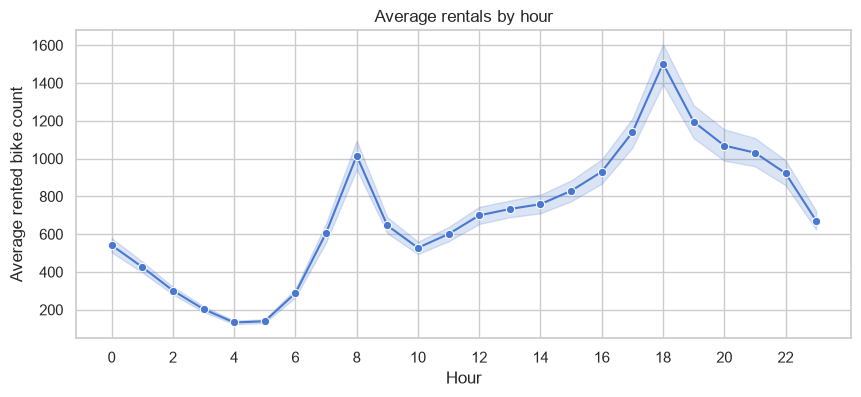

In [ ]:
plt.figure(figsize=(10, 4))
# 그래프 크기 설정 (데이터 많을수록 가로 크기 늘리면 가독성이 좋아짐)
sns.lineplot(data=df, x="hour", y="rent_count", marker="o")
plt.title("Average rentals by hour")
plt.xlabel("Hour")
plt.ylabel("Average rented bike count")
plt.xticks(range(0, 24, 2))
plt.show()

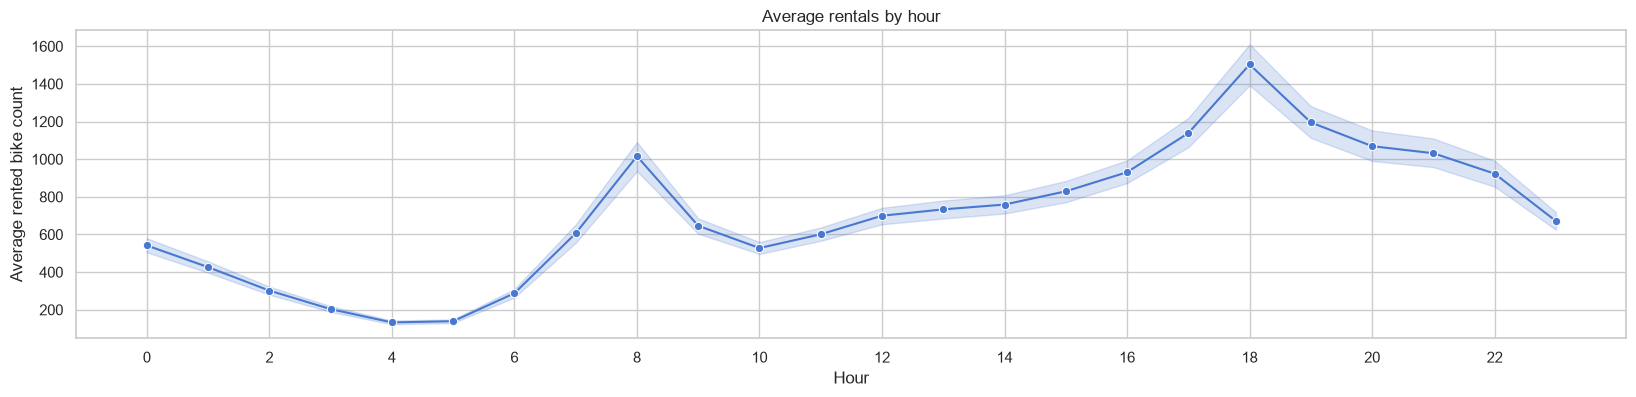

In [31]:
plt.figure(figsize=(20, 4))
sns.lineplot(data=df, x="hour", y="rent_count", marker="o")
plt.title("Average rentals by hour")
plt.xlabel("Hour")
plt.ylabel("Average rented bike count")
plt.xticks(range(0, 24, 2))
plt.show()

**봉우리가 두 개** 보이시죠. 

숫자 표에서는 잘 안 보이던 게 그림에서는 한눈에 들어옵니다. 이게 그래프를 그리는 이유예요.

> 선 주변의 옅은 띠는 신뢰구간입니다. 신뢰구간을 표현하는 방법은 다양하지만, 여기서는 얼마나 영역이 굵느냐에 따라서 어렵게 생각하지 마시고 "이 시간대는 날마다 편차가 크구나" 정도로 읽으시면 됩니다.

### ✍️ 나의 인사이트 — Q1. 시간대

2~3문장으로 적어주세요. 정답을 맞히는 칸이 아니니까 편하게 쓰시면 됩니다!

- 봉우리 두 개는 각각 몇 시인가요?
- 왜 하필 그 시간에 봉우리가 생겼을까요? 짐작되는 이유를 적어주세요.
- 가장 적게 빌리는 시간은 몇 시인가요?
- 신뢰구간에 대해서 본인이 아는거, 또는 추가로 조사해본것도 정리해주세요

**작성:**

> 봉우리는 8시와 18시 -> 출퇴근 시간 때문? / 가장 적게 빌리는 시간은 새벽 5시경 -> 술먹는 사람도 집에 갈 시간? / 신뢰구간 : 통계학적 의미는 표본데이터를 바탕으로 알 수 없는 모집단의 진짜값(모수)이 존재할 것으로 예상되는 값의 범위, 하나의 값만 찍어서 추정하는 '점추정'의 불확실성을 보완하기 위해, 초소한 이 범위에 참값이 들어있을 것이라며 제시하는 범위 - '그나마 내가 확실히 말할 수 있는 정도'

## Q2. 계절에 따라 다를까?

2-2에서 이미 숫자는 구했습니다. 이번엔 그래프로 그려볼게요.

`barplot`은 그룹별 평균을 막대로 그려줍니다. 순서를 정해주지 않으면 알파벳순으로 나와서 `order`로 계절 순서를 직접 넘겼어요.

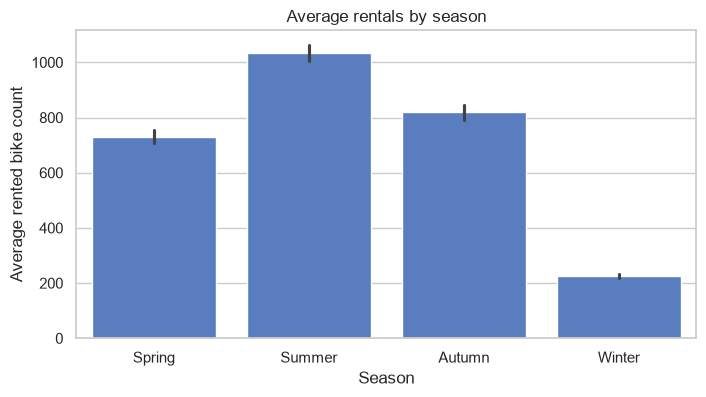

In [32]:
season_order = ["Spring", "Summer", "Autumn", "Winter"]

plt.figure(figsize=(8, 4))
sns.barplot(data=df, x="season", y="rent_count", order=season_order)
plt.title("Average rentals by season")
plt.xlabel("Season")
plt.ylabel("Average rented bike count")
plt.show()

겨울이 확연히 적습니다. 근데 데이터가 적어지면 아까 우리가 봤던 형태의 그래프가 나올까요?

이부분도 통계적으로 생각해보셨으면 좋을거같아요!

이걸 확인하려면 시간과 계절을 **동시에** 봐야 합니다. seaborn에서는 `hue=`에 열 이름을 하나 더 넣기만 하면 돼요. Q1 코드에서 한 줄만 늘었습니다.

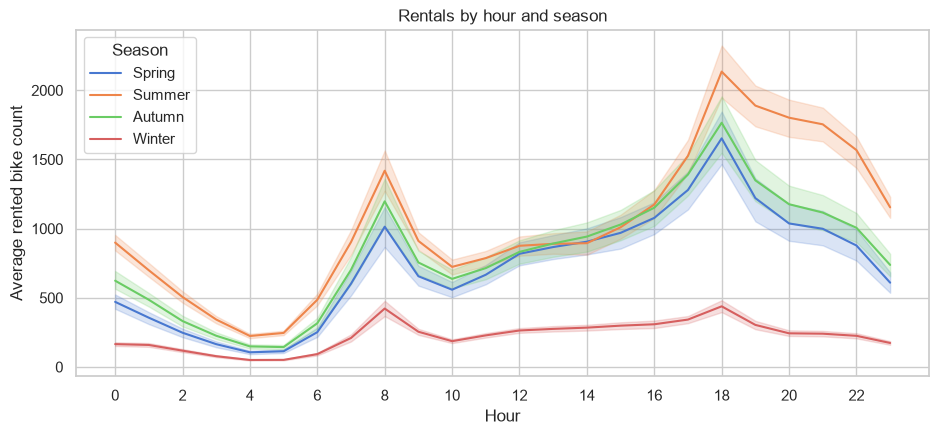

In [ ]:
plt.figure(figsize=(11, 4.5))
sns.lineplot(data=df, x="hour", y="rent_count", hue="season",
             hue_order=season_order)
# sns.lineplot()은 같은 조건 데이터가 여러개 있으면 기본적으로 평균 계산
# -> df.groupby(["season", "hour"])["rent_count"].mean()이 실행되고 있는 것
# hue를 사용하면 하나의 그래프에 여러 그룹을 색상으로 표기할 수 있음
plt.title("Rentals by hour and season")
plt.xlabel("Hour")
plt.ylabel("Average rented bike count")
plt.xticks(range(0, 24, 2))
plt.legend(title="Season")
plt.show()

### ✍️ 나의 인사이트 — Q2. 계절

2~3문장으로 적어주세요. 정답을 맞히는 칸이 아니니까 편하게 쓰시면 됩니다!

- 다른 계절들하고 데이터 차이는 어떤 영향을 주는걸까요?
- 겨울에는 모양이 어떻게 달라졌나요?
- 단순하게 추워서 그랬을까요...?

**작성:**

> 다른 계절들하고 데이터 차이 영향은 잘 모르겠음. 겨울에는 모든 시간대에서의 이용이 줄어든 것으로 보임. 단순히 추워서 그랬다기에는 더운 여름의 이용이 가장 많음. -> 계절의 문제만은 아닐 것. 다른 계절보다 18시의 이용량이 다른 시간대대비 낮은 것을 볼 수 있음. => 18시 이후로 날씨가 더 추워지기 시작하고 다른 계절보다 낮시간이 짧아 금방 어두워져서? <-> 여름은 해가 길고 18시 이후로 선선해져서 자전거 타기 좋음

## Q3. 평일과 주말이 다를까?

이 질문에 답하려면 **요일 정보가 필요한데, 데이터에 없습니다.** 있는 건 `date`뿐이에요.

없으면 만들면 됩니다. 이렇게 원래 열에서 새 열을 뽑아내는 걸 **파생 변수**라고 부릅니다.

### 3-1. 날짜에서 요일 뽑아내기

`date`는 지금 그냥 글자입니다. `"01/12/2017"`처럼요. 글자 상태에서는 "이 날이 무슨 요일이야?"라고 물어볼 수 없어요.

`pd.to_datetime()`으로 **날짜 타입**으로 바꿔주면 `.dt`를 붙여서 요일·월·연도를 꺼낼 수 있습니다.

In [15]:
df["date"] = pd.to_datetime(df["date"], format="%d/%m/%Y")
df["weekday"] = df["date"].dt.day_name().str[:3]
df["is_weekend"] = df["weekday"].isin(["Sat", "Sun"])

df[["date", "hour", "weekday", "is_weekend", "rent_count"]].head()

,date,hour,weekday,is_weekend,rent_count
0,2017-12-01,0,Fri,False,254
1,2017-12-01,1,Fri,False,204
2,2017-12-01,2,Fri,False,173
3,2017-12-01,3,Fri,False,107
4,2017-12-01,4,Fri,False,78


세 줄이 각각 하는 일입니다.

1. `to_datetime`: 글자 `"01/12/2017"`을 날짜로 바꿉니다. `format="%d/%m/%Y"`는 "일/월/연도 순서로 적혀 있다"고 알려주는 것이에요. **이걸 안 알려주면 12월 1일과 1월 12일을 헷갈립니다**
2. `.dt.day_name()`: 요일 이름(`Monday`)을 꺼냅니다. `.str[:3]`으로 앞 세 글자만 잘라서 `Mon`으로 만들었어요
3. `.isin([...])`: 토·일이면 `True`, 아니면 `False`인 열을 만듭니다

### 3-2. 요일별로 보기

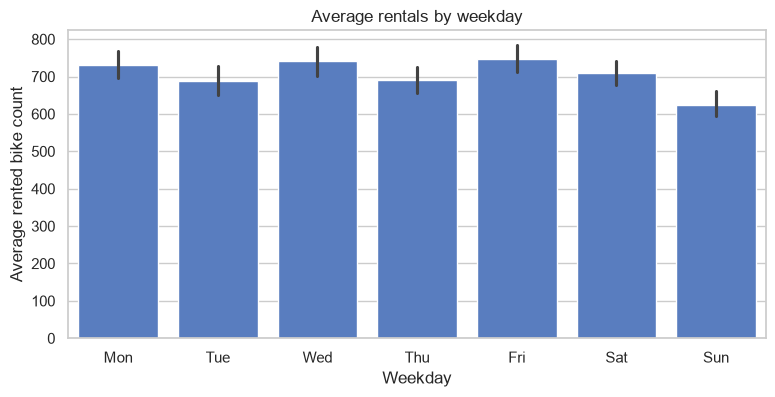

weekday
Mon    730.6
Tue    688.0
Wed    740.3
Thu    690.7
Fri    747.1
Sat    709.5
Sun    625.2
Name: rent_count, dtype: float64


In [16]:
weekday_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

plt.figure(figsize=(9, 4))
sns.barplot(data=df, x="weekday", y="rent_count", order=weekday_order)
plt.title("Average rentals by weekday")
plt.xlabel("Weekday")
plt.ylabel("Average rented bike count")
plt.show()

print(df.groupby("weekday")["rent_count"].mean().reindex(weekday_order).round(1))

평균만 보면 요일별 차이가 생각보다 작습니다. 그러면 시간대는 다를까요?

 Q2에서 썼던 `hue`를 여기에도 써보겠습니다.

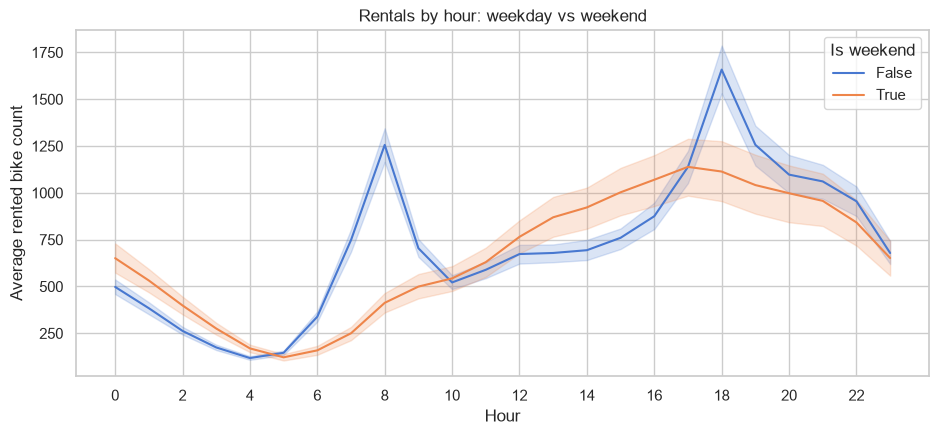

In [17]:
plt.figure(figsize=(11, 4.5))
sns.lineplot(data=df, x="hour", y="rent_count", hue="is_weekend")
plt.title("Rentals by hour: weekday vs weekend")
plt.xlabel("Hour")
plt.ylabel("Average rented bike count")
plt.xticks(range(0, 24, 2))
plt.legend(title="Is weekend")
plt.show()

생각보다 차이가 크네요

평균 하나만 보고 "차이 없네"라고 넘어갔다면 못 봤을 그림인데, 한번 더 분석하니깐 다른 인사이트가 나오게 됬어요 

> 💡 **평균이 같다고 분포가 같은 건 아닙니다.**

### ✍️ 나의 인사이트 — Q3. 평일과 주말

2~3문장으로 적어주세요. 정답을 맞히는 칸이 아니니까 편하게 쓰시면 됩니다!

- 평일 그래프와 주말 그래프의 모양이 어떻게 다른가요?
- 주말에는 언제 가장 많이 빌리나요? 평일과 몇 시간 차이가 나나요?
- 요일별 막대그래프만 봤다면 놓쳤을 사실은 무엇인가요?

**작성:**

> 평일은 8시, 18시에 이용이 눈에 띄게 크게 나타나지만 주말은 전체적으로 6시 이후로 완만하게 상승하고 17시 이후로 완만하게 하강하는 모습을 보임. 이용이 가장 많은 시간은 평일보다 1시간 이른 17시. 막대그래프만 봤다면 일주일 동안 자전거 이용은 비슷하다고 생각했을 것 -> 따릉이 분석에는 요일 특히 평일/주말 + 시간대가 중요함

## Q4. 날씨는 영향을 줄까?

### 4-1. 기온과 대여량 — 산점도

지금까지는 "그룹별 평균"을 봤습니다. 이번에는 **숫자 두 개의 관계**를 봅니다.

산점도는 점 하나가 한 줄(= 한 시간)입니다. 점이 8,760개나 되면 서로 겹쳐서 뭉개지기 때문에, `alpha`로 반투명하게 만들었어요. 진한 곳일수록 점이 많이 몰려 있다는 뜻입니다.

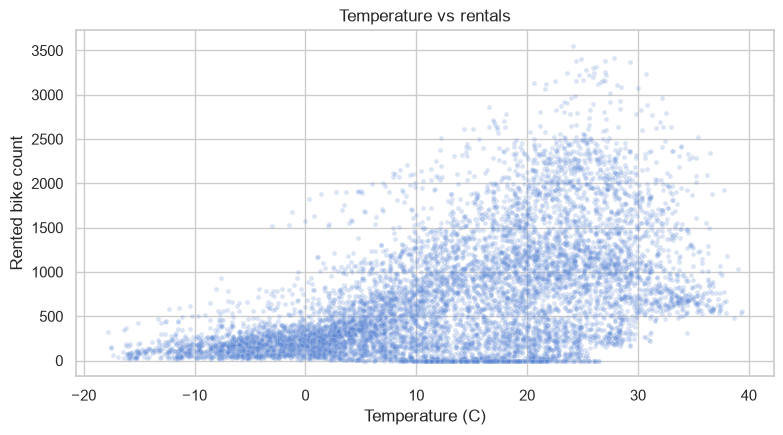

In [ ]:
plt.figure(figsize=(9, 4.5))
sns.scatterplot(data=df, x="temp", y="rent_count", alpha=0.2, s=12)
# s = 점크기
plt.title("Temperature vs rentals")
plt.xlabel("Temperature (C)")
plt.ylabel("Rented bike count")
plt.show()

### 4-2. 비가 오면 안 탈까?

`rain` 열은 강수량(mm)입니다. `> 0`이면 비가 조금이라도 왔다는 거겠죠?

          count   mean
is_rainy              
False      8232  739.3
True        528  163.5


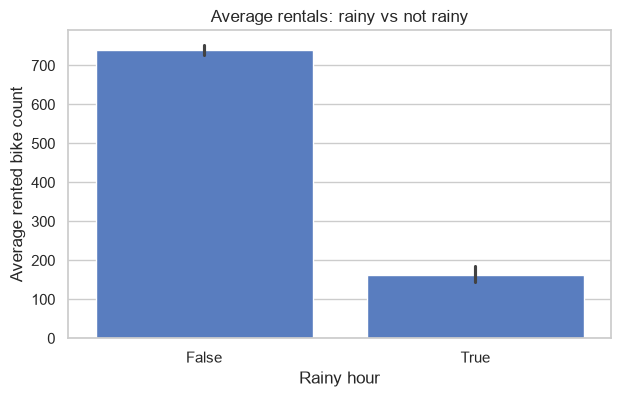

In [19]:
df["is_rainy"] = df["rain"] > 0

print(df.groupby("is_rainy")["rent_count"].agg(["count", "mean"]).round(1))

plt.figure(figsize=(7, 4))
sns.barplot(data=df, x="is_rainy", y="rent_count")
plt.title("Average rentals: rainy vs not rainy")
plt.xlabel("Rainy hour")
plt.ylabel("Average rented bike count")
plt.show()

### ✍️ 나의 인사이트 — Q4. 날씨

2~3문장으로 적어주세요. 정답을 맞히는 칸이 아니니까 편하게 쓰시면 됩니다!

- 산점도에서 기온이 올라갈수록 대여량은 어떻게 되나요? 아주 더울 때(30도 이상)는요?
- 비가 오면 어떻게 달라지나요?

**작성:**

> 기온이 올라갈수록 대여량 증가하다가 약 25도를 기준으로 감소하는 경향을 보임. 오히려 30도 이상일 때 대여량이 500 이상인 경우가 다른 기온보다 많음(여름에 대여량이 많기 때문?) / 비가 오면 예상대로 대여량이 크게 감소

## Q5. 문 닫은 날은 어떻게 처리하지?

1-5에서 봤던 `is_open`의 `No` 295개를 기억하시나요? 이제 확인할 차례입니다.

### 5-1. 운영하지 않은 시간 들여다보기

In [37]:
closed = df[df["is_open"] == "No"]

print("운영하지 않은 시간:", len(closed), "개")
# len은 행의 개수 반환
print("그 시간의 대여량 최댓값:", closed["rent_count"].max())
print("그 시간의 대여량 평균:", closed["rent_count"].mean())

운영하지 않은 시간: 295 개
그 시간의 대여량 최댓값: 0
그 시간의 대여량 평균: 0.0


**295시간이 전부 0대입니다.** 당연하죠. 문을 닫았으니까요.

문제는 이 0들이 **지금까지 우리가 본 모든 평균에 섞여 있었다는 것**입니다. 얼마나 영향을 줬는지 확인해봅시다.

### 5-2. 평균이 얼마나 달라지나

In [21]:
print("전체 평균      :", round(df["rent_count"].mean(), 1))
print("운영한 시간만  :", round(df[df["is_open"] == "Yes"]["rent_count"].mean(), 1))

전체 평균      : 704.6
운영한 시간만  : 729.2


25대 정도 차이가 납니다. 생각보다 작죠? 8,760시간 중 295시간이라 비중이 작아서 그렇습니다.

**중요한 건 차이의 크기가 아니라 판단 자체입니다.** 이 질문에 답하셔야 해요.

> "따릉이가 하루 평균 몇 대 대여되는지 알고 싶다"고 할 때, **문 닫은 시간을 포함해야 할까요?**

- 포함한다 → "따릉이 시스템 전체의 하루 평균" (운영 중단도 현실의 일부니까)
- 제외한다 → "따릉이가 열려 있을 때의 수요" (수요를 알고 싶은 거니까)

**둘 다 맞습니다.** 무엇을 알고 싶은지에 따라 달라져요. 정답이 없다는 게 오늘의 마지막 교훈입니다.

> 💡 **평균을 낼 때 어떤 행을 넣을지 정하는 것도 분석입니다.** 코드가 자동으로 정해주지 않아요.

### 5-3. 운영한 시간만 다시 그려보기

Q1의 그래프를 문 닫은 시간을 빼고 다시 그려보겠습니다.

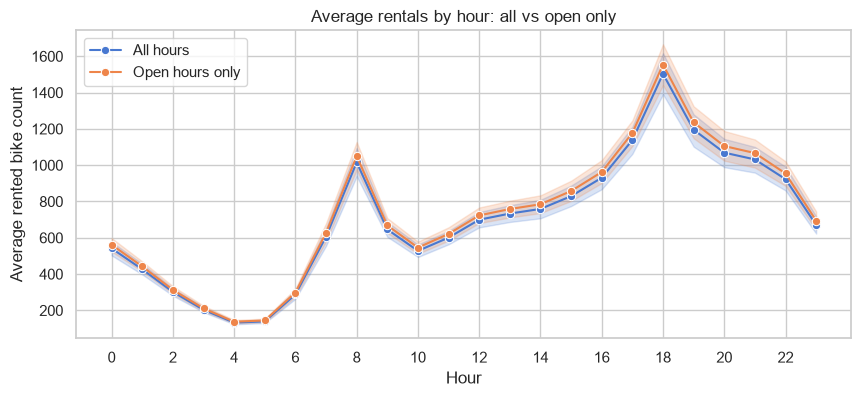

In [ ]:
open_df = df[df["is_open"] == "Yes"]

plt.figure(figsize=(10, 4))
sns.lineplot(data=df, x="hour", y="rent_count", marker="o", label="All hours")
sns.lineplot(data=open_df, x="hour", y="rent_count", marker="o", label="Open hours only")
plt.title("Average rentals by hour: all vs open only")
plt.xlabel("Hour")
plt.ylabel("Average rented bike count")
plt.xticks(range(0, 24, 2))
plt.legend()
# 그래프에서 각 색생, 선, 마커가 무엇을 의미하는지 설명하는 상자를 표시
plt.show()

## 🛠 직접 해보기

여유 되시는 분만 하시면 됩니다. 안 하셔도 다음 회차 진행에는 전혀 지장 없어요!

**1단계 — 열 이름만 바꾸면 되는 것**

1. `humidity`(습도)와 대여량의 산점도를 그려보세요. (Q4 코드에서 `x`만 바꾸면 됩니다)
2. `holiday`(공휴일 여부)별 평균 대여량을 구해보세요. (`groupby` 기준만 바꾸면 됩니다)

**2단계 — 한 줄 더 쓰는 것**

3. `hue="is_rainy"`를 넣어서, 비 오는 날과 안 오는 날의 시간대별 패턴을 한 그래프에 그려보세요.
4. `df["month"] = df["date"].dt.month`로 월 열을 만든 뒤, 월별 평균 대여량을 그려보세요.

**3단계 — 도전**

5. `df.groupby(["season", "hour"])["rent_count"].mean()`을 실행해보세요. 기준을 **두 개** 넣으면 어떤 결과가 나오나요?

💡 막히시면 위에 있는 코드를 복사해서 열 이름만 바꿔보세요. 

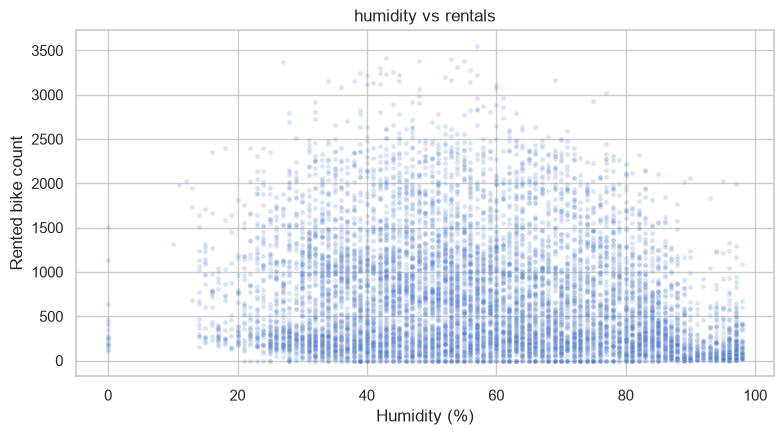

In [38]:
# 1번: 습도와 대여량 산점도

plt.figure(figsize=(9, 4.5))
sns.scatterplot(data=df, x="humidity", y="rent_count", alpha=0.2, s=12)
plt.title("humidity vs rentals")
plt.xlabel("Humidity (%)")
plt.ylabel("Rented bike count")
plt.show()

In [ ]:
# 2번: 공휴일 여부별 평균 대여량

df.head()
is_holiday = df[df["holiday"] != "No Holiday"]

plt.figure(figuresize = (7, 4))
sns.barplot(data = df, x = "Holiday", y = "Average bike count")

In [25]:
# 3~5번: 자유롭게 써보세요

## 📎 부록. 인코딩이 뭔가요?

1-2에서 `encoding="latin1"`을 썼던 이유입니다. 궁금하신 분만 읽으시면 됩니다.

컴퓨터는 글자를 그대로 저장하지 못합니다. 전부 숫자로 바꿔서 저장해요. 그래서 **"어떤 글자를 몇 번으로 저장할지" 미리 정해둔 약속표**가 필요한데, 이걸 인코딩이라고 부릅니다.

문제는 이 약속표가 하나가 아니라는 점입니다. **저장할 때 쓴 표와 읽을 때 쓴 표가 다르면 글자가 깨집니다.** 엑셀에서 CSV를 열었는데 한글이 `���`처럼 보였던 경험 있으시죠? 딱 그 상황이에요.

| 인코딩 | 어떤 약속표인가요 | 주로 어디서 만나나요 |
| --- | --- | --- |
| `utf-8` | 한글·한자·이모지까지 전 세계 문자를 다 담은 표. 지금의 사실상 표준 | 요즘 만들어진 파일 대부분 |
| `cp949` (= `euc-kr`) | 윈도우 한국어판이 오래 쓰던 한글용 표 | 국내 공공데이터 CSV, 엑셀에서 저장한 파일 |
| `latin1` (= `iso-8859-1`) | 서유럽 알파벳용 표 | 해외 데이터셋, 오래된 파일 |

이 데이터가 `latin1`인 이유는 열 이름에 있습니다. `Temperature(°C)`의 **`°` 기호** 때문이에요. 아래 셀을 실행해서 직접 확인해보세요.

In [26]:
for encoding in ["utf-8", "cp949", "latin1"]:
    try:
        sample = pd.read_csv(LOCAL_CSV, encoding=encoding, nrows=1)
        print(f"{encoding:8s} 성공 → 네 번째 열 이름: {sample.columns[3]}")
    except Exception as error:
        print(f"{encoding:8s} 실패 → {type(error).__name__}")

utf-8    실패 → UnicodeDecodeError
cp949    성공 → 네 번째 열 이름: Temperature(캜)
latin1   성공 → 네 번째 열 이름: Temperature(°C)


`utf-8`은 아예 에러가 나고, `cp949`는 에러 없이 읽히지만 `°` 자리에 엉뚱한 글자가 들어갑니다. **에러가 안 났다고 제대로 읽힌 건 아니라는 점**이 인코딩에서 가장 조심할 부분이에요.

> 💡 **실무 팁**: CSV를 읽다가 에러가 나거나 글자가 깨지면 `encoding`을 `"utf-8"` → `"cp949"` → `"latin1"` 순서로 바꿔가며 시도해보세요. 대부분 이 셋 안에서 해결됩니다.